Loaded: ..\data\processed\mie_materials_v1.npz
Wavelengths : (61,)
Combos      : (700,)
Radii       : (700,)
sigma_sca   : (700, 61)
sigma_abs   : (700, 61)
Mode          : PEAK_MODE=1 (scattering-anchored)
Total peaks   : 979
Unique combos : 700
Lookup source : global-only (700 rows)
combo_lookup  : 700 rows | materials: 7
State dim: (9,)
Initial state: [0.57575756 0.         0.21666667 0.4796807  0.03722818 0.
 0.5978853  0.6498103  0.24634235]
{'material': 'Ag', 'radius_nm': 667.9363124544254, 'peak_wl': 440.0, 'sca_sig': 4352379.775109646, 'abs_sig': 97156.10530921018, 'is_global': True, 'target_wl': 300.0, 'target_sca': 5386553.762642151, 'target_abs': 1754403.9313939845, 'wl_err': 140.0, 'sca_sig_err': 1034173.9875325048, 'abs_sig_err': 1657247.8260847742, 'combined_error': 0.25956754891474454, 'steps': 1}
Device: cuda
Ep  100 | eps=0.819 | avg_reward=  -0.18 | avg_combined_error=0.3648
Ep  200 | eps=0.670 | avg_reward=  -0.06 | avg_combined_error=0.3729
Ep  300 | eps=0.548 | avg

,material,radius_nm,peak_nm,lambda_diff,lambda_sq_error,sca_sigma_nm2,sigma_sca_diff,sigma_sca_sq_error,abs_sigma_nm2,sigma_abs_diff,sigma_abs_sq_error,combined_error,is_global
0,Si,223.700735,700.0,0.0,0.0,7.409994e+05,-1.590006e+05,2.528118e+10,70801.261084,-329198.738916,1.083718e+11,0.013965,True
1,GaAs,198.328707,700.0,0.0,0.0,2.687824e+05,-6.312176e+05,3.984357e+11,107294.152293,-292705.847707,8.567671e+10,0.017859,True
2,Cu,231.554760,700.0,0.0,0.0,5.249205e+05,-3.750795e+05,1.406846e+11,20489.893825,-379510.106175,1.440279e+11,0.018230,True
3,Cu,231.086682,700.0,0.0,0.0,5.233764e+05,-3.766236e+05,1.418453e+11,20447.352700,-379552.647300,1.440602e+11,0.018249,True
4,Si,228.033109,710.0,10.0,100.0,7.714756e+05,-1.285244e+05,1.651852e+10,66963.987698,-333036.012302,1.109130e+11,0.027102,True
5,Si,225.582814,710.0,10.0,100.0,7.089570e+05,-1.910430e+05,3.649742e+10,67687.572998,-332312.427002,1.104315e+11,0.027770,True
6,Si,365.223223,710.0,10.0,100.0,1.446170e+06,5.461702e+05,2.983019e+11,157627.940602,-242372.059398,5.874422e+10,0.028383,True
7,Cu,234.326082,710.0,10.0,100.0,5.342562e+05,-3.657438e+05,1.337685e+11,20187.783837,-379812.216163,1.442573e+11,0.031471,True
8,Au,223.796158,690.0,-10.0,100.0,5.114693e+05,-3.885307e+05,1.509561e+11,13932.415296,-386067.584704,1.490482e+11,0.031956,True
9,Cu,128.668147,710.0,10.0,100.0,1.819841e+05,-7.180159e+05,5.155469e+11,7369.892614,-392630.107386,1.541584e+11,0.035860,True


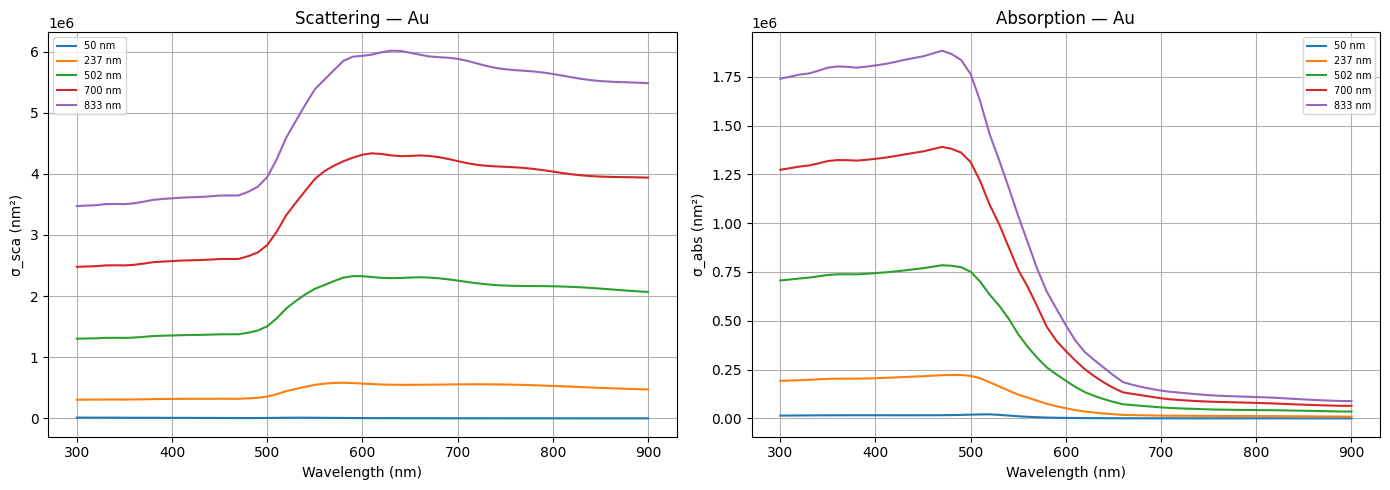

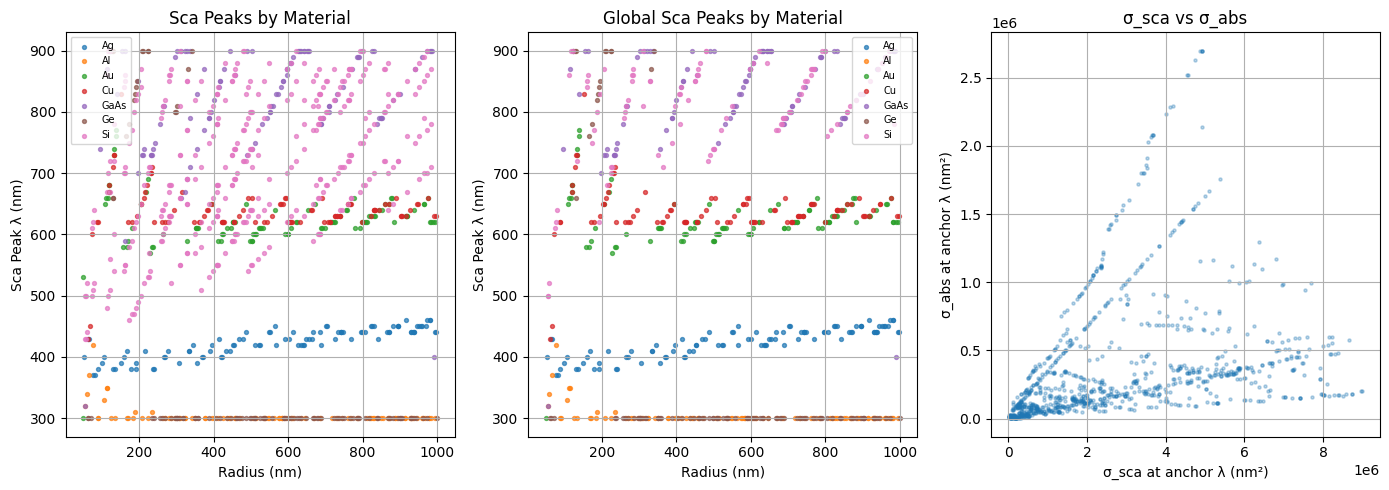

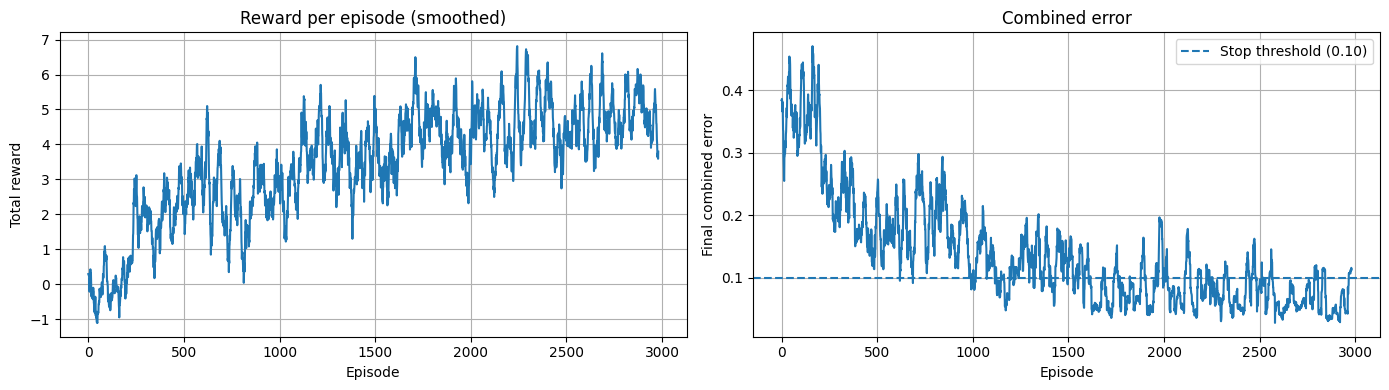

In [2]:
# Clean notebook version: keep this file as cells in Jupyter if you want.
import sys
sys.path.append("..")
from src.data_utils import load_mie_data
from src.peak_utils import build_peak_dataframe, build_combo_lookup, ErrorWeights
from src.env import MieEnv
from src.train import TrainConfig, train_dqn
from src.evaluate import query, brute_force_search
from src.plotting import plot_material_curves, plot_peak_summary, plot_training_curves

DATA_PATH = "../data/processed/mie_materials_v1.npz"

PEAK_MODE = 1
GLOBAL_ONLY = 1
PROMINENCE_FRAC = 0.14
weights = ErrorWeights(peak_wl=0.80, sca_sig=0.10, abs_sig=0.10)

data = load_mie_data(DATA_PATH)
plot_material_curves(data, material_name="Au")
peak_df = build_peak_dataframe(data, peak_mode=PEAK_MODE, prominence_frac=PROMINENCE_FRAC)
plot_peak_summary(peak_df, peak_mode=PEAK_MODE)

combo_lookup, scales = build_combo_lookup(peak_df, global_only=GLOBAL_ONLY)
combo_lookup.head()

env = MieEnv(
    combo_lookup=combo_lookup,
    peak_mode=PEAK_MODE,
    global_only=GLOBAL_ONLY,
    scales=scales,
    weights=weights,
)

state = env.reset()
print("State dim:", state.shape)
print("Initial state:", state)
print(env.step(1)[3])

# 4) Train DQN
config = TrainConfig(
    episodes=3000,
    batch_size=128,
    gamma=0.99,
    lr=1e-4,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.998,
    target_update=500,
    hidden=256,
    buffer_cap=50_000,
    min_buffer=1_000,
    print_every=100,
)

online_net, history = train_dqn(env, config=config)
plot_training_curves(history, stop_threshold=MieEnv.STOP_THRESHOLD)

results_1 = query(
    online_net,
    env,
    target_wl=648,
    target_sca=771_369,
    target_abs=500_000,
)

results_2 = query(
    online_net,
    env,
    target_wl=700,
    target_sca=900_000,
    target_abs=400_000,
)

bf_1 = brute_force_search(
    combo_lookup,
    target_wl=700,
    target_sca=900_000,
    target_abs=400_000,
    scales=scales,
    weights=weights,
    top_k=20,
)

bf_1
